
# Project: Patients' Appointment dataset analysis and report
## Date of project: May 29, 2022 as a project under the Udacity Data Analytics Nanodegree program at <ul> <a href="https://www.udacity.com/enrollment/nd002-alg-t2" >here</a> </ul>

## Table of Contents
<ul>
<li><a href="#intro">Introduction</a></li>
<li><a href="#wrangling">Data Wrangling</a></li>
<li><a href="#eda">Exploratory Data Analysis</a></li>
<li><a href="#conclusions">Conclusions</a></li>
</ul>

<a id='intro'></a>
## Introduction

### Dataset Description

This is a dataset that shows the record of whether patients showed up for their appoitment with their doctor. The aim of the analysis is to analyse which characteristics of the patients made them missed their appointment. Some columns in the dataset are characteristics of the patients which could have possible effect on whether or not the patients missed their medical appointment. These characteristics include but not limited to age, neighbourhood, scholarship, hypertension, diabetes,alcoholism, sms_received etc.


#### Explanation of some column
1. age - This indicate the age of the patients
2. neighbourhood - This indicate the location of the hospital
3. scholarship - This indicate if the patient is subcribed to 'BOLSA FAMILIA'
4. hypertension - This indicate if the patient has hypertension or not
5. diabetes - This shows whether the patient has diabetes or not
6. alcoholism - This indicate if the patient is suffering from alcoholism or not
7. sms_received etc. This shows if patient recieved an SMS reminder or not
8. no-show - This indicate whether the patient show up or missed their medical appointment. It reads **yes** to say that a patients missed their medical appointment; otherwise, they showed up.

### Question(s) for Analysis

1. what characteristics of patients can be used to predict if patients would miss their medical appointment
2. what characteristics of patients actually influnced patients to miss their medical appointment



In [ ]:
#import pandas as pd
#import numpy as np
#import matplotlib.pyplot as plt
#import seaborn as sns
#%matplotlib inline





In [ ]:
#!pip install --upgrade pandas==0.25.0

<a id='wrangling'></a>
## Data Wrangling



### General Properties


#### First step is to load the data into a data frame.

#### Upload the dataset

To ensure the notebook can find the `noshowappointments_2016.csv` file, please upload it to your Colab environment using the following code. After running the cell, a button will appear allowing you to select and upload the file from your local machine.

After uploading the file, you can proceed with loading the data into a DataFrame.

In [ ]:
#importing and reading thte csv file
#nsa2016_df = pd.read_csv('noshowappointments_2016.csv')


In [ ]:
#generalinformation
nsa2016_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


>It is observed that the data set has floats, object and integer data types

>The dataset contains 110527 patients record and 14 columns which discribes some characteristics of the patients

#### Deriving some insights from the general statistics of the dataset

In [ ]:
#general statistics of the data set
nsa2016_df.describe()

,PatientId,AppointmentID,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received
count,1.105270e+05,1.105270e+05,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,1.474963e+14,5.675305e+06,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026
std,2.560949e+14,7.129575e+04,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873
min,3.921784e+04,5.030230e+06,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172614e+12,5.640286e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173184e+13,5.680573e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.439172e+13,5.725524e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,9.999816e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000


>The mean age is around 37 years, the minimum age is -1 which presents an analytic problem, and the maximum age is 115 years which is contrary due to the life expectancy in brazil.

**Age** distribution

In [ ]:
nsa2016_df.Gender.value_counts()

,count
Gender,
F,71840
M,38687


> More female patients are involved in this analysis than male. That may present a little limitation to our analysis especially with respect to gender.

Number of patients that **showed up** and those who **missed**

In [ ]:
nsa2016_df['No-show'].value_counts()

,count
No-show,
No,88208
Yes,22319


>The result revealed that more patients showed up for their medical appointment than those who missed

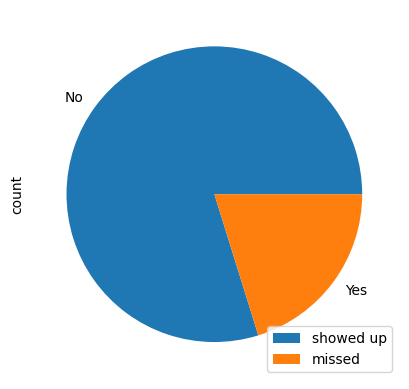

In [ ]:
#using visuals for further illustration
nsa2016_df['No-show'].value_counts().plot( kind = 'pie')
plt.legend(['showed up','missed']);

#### Insights from the statistics

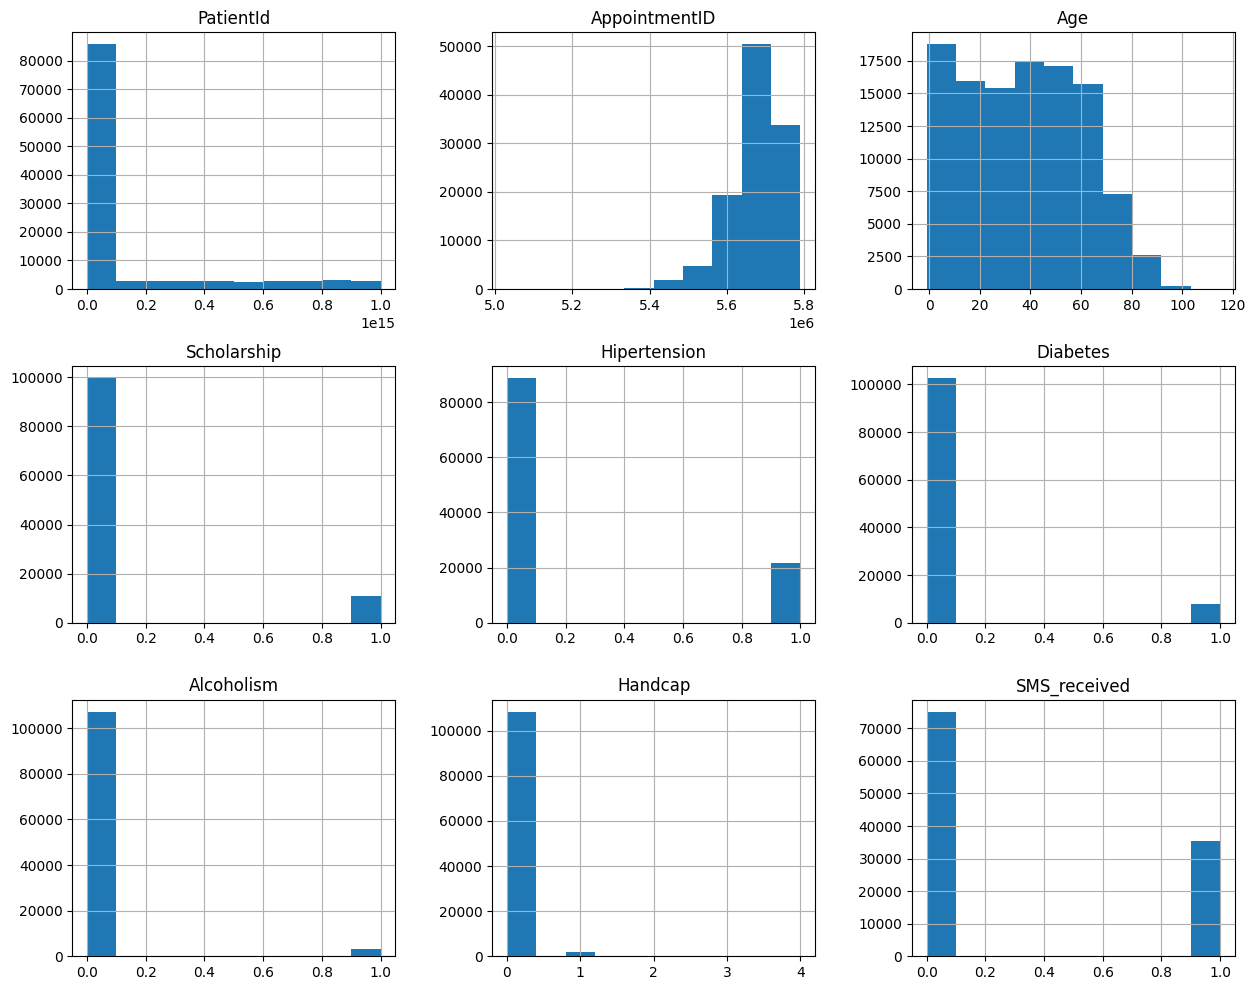

In [ ]:
#general histogram information
nsa2016_df.hist(figsize = (15,12));


>The **patientid** and **appointmentID** are columns that can not be analysed in an aggregate manner, hence these columns will be dropped.

> The age histogram is skewed to the right, hence we have patients who are above the mean age.

> We have less patients who are either **alcoholics**, **handicapped**, **hypertensive** or **diabetic** than those who are not.

> More patients are enrolled in the Bolsa Familia Welfare program than those who are not.

> About 30% of the number of patients recieved sms reminders for their medical appointment


### Data Cleaning


#### Changing all columns' names to small letters
First, the columns' names will be changed to lower cases for easy coding, then the columns' names will be printed to confirm

In [ ]:
nsa2016_df.columns = nsa2016_df.columns.str.lower()
nsa2016_df.columns

Index(['patientid', 'appointmentid', 'gender', 'scheduledday',
       'appointmentday', 'age', 'neighbourhood', 'scholarship', 'hipertension',
       'diabetes', 'alcoholism', 'handcap', 'sms_received', 'no-show'],
      dtype='object')

#### Renaming some columns
Here some columns that are incorrectly spelt or written will be renamed so that the concerned invariabes could be properly analyzed.

The first is:

From **hipertension** to **hypertension**

In [ ]:
#rename hipertension
nsa2016_df.rename(columns={'hipertension':'hypertension'}, inplace=True)

Here, the **no-show** column is renamed to **no_show** for easy coding and analysis

In [ ]:
#rename no-show
nsa2016_df.rename(columns={'no-show':'no_show'}, inplace=True)

Next, **handcap** is correctly spelt or changed to **handicap**

In [ ]:
#rename handcap
nsa2016_df.rename(columns={'handcap':'handicap'}, inplace=True)

Now, to confirm whether the changes has taken place;

In [ ]:
nsa2016_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   patientid       110527 non-null  float64
 1   appointmentid   110527 non-null  int64  
 2   gender          110527 non-null  object 
 3   scheduledday    110527 non-null  object 
 4   appointmentday  110527 non-null  object 
 5   age             110527 non-null  int64  
 6   neighbourhood   110527 non-null  object 
 7   scholarship     110527 non-null  int64  
 8   hypertension    110527 non-null  int64  
 9   diabetes        110527 non-null  int64  
 10  alcoholism      110527 non-null  int64  
 11  handicap        110527 non-null  int64  
 12  sms_received    110527 non-null  int64  
 13  no_show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


> The changes have been effected

#### Now, it will be ensured that columns that have unique values  (e.g 1&0, and yes & no) were accurately entered

In [ ]:
#defining a funtion to simply check the number of unique values of the data entered in the columns

def unik_all():
    unik1 = nsa2016_df['hypertension'].nunique() #for hypertension column
    unik2 = nsa2016_df['diabetes'].nunique() #for diabete column
    unik3 = nsa2016_df['alcoholism'].nunique() #for alcoholism column
    unik4 = nsa2016_df['sms_received'].nunique() #for sms_recieved column
    unik5 = nsa2016_df['no_show'].nunique() #for no_show column
    unik6 = nsa2016_df['handicap'].nunique() #for handicap column

    print(unik1, unik2, unik3, unik4, unik5, unik6) #printing all number of unique values



#### Input

In [ ]:
unik_all()

2 2 2 2 2 5


>All the above columns have correct data entry, since they show unique values. In addition, the 'handicap' column has five unique values, which is seen last.

#### Duplicate values
Now, to inspect for duplicates, afterwhich we'll drop some columns not needed for this analysis.

In [ ]:
#checking for and removing duplicate
nsa2016_df.duplicated().sum()

np.int64(0)

#### Null values
Null values is investigated here

In [ ]:
#checking for null values
nsa2016_df.isnull().sum()

,0
patientid,0
appointmentid,0
gender,0
scheduledday,0
appointmentday,0
age,0
neighbourhood,0
scholarship,0
hypertension,0
diabetes,0


> All columns had no null entry

#### Dropping unwanted columns

Columns that will not be needed for the purpose of this project will be dropped. These data are not important for answering the project questions, however they could be necessary for other analysis. Columns to be dropped include those columns that are perculiar to each patient and are not able to be analysed in an aggregate manner. They include patientId, appointmentid, scheduledday, appointmentday. For this analysis, we need columns of medical coonditions of patients, medical welfare, and age.

In [ ]:
#dropping some columns
nsa2016_df.drop(['patientid','appointmentid','scheduledday','appointmentday', 'neighbourhood'], axis = 1, inplace=True)

In [ ]:
#checking for effected changes
nsa2016_df.head()

,gender,age,scholarship,hypertension,diabetes,alcoholism,handicap,sms_received,no_show
0,F,62,0,1,0,0,0,0,No
1,M,56,0,0,0,0,0,0,No
2,F,62,0,0,0,0,0,0,No
3,F,8,0,0,0,0,0,0,No
4,F,56,0,1,1,0,0,0,No


>Great! Now the analysis can be more specific on the patients' characteristics.

#### Changing the datatype of the no_show column to make it easy for further analysis

In [ ]:
nsa2016_df['no_show'].replace('No','1',inplace=True)
nsa2016_df['no_show'].replace('Yes','0',inplace=True)
nsa2016_df['no_show'] = nsa2016_df.no_show.astype('int64')

/tmp/ipykernel_914/1815387282.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  nsa2016_df['no_show'].replace('No','1',inplace=True)
/tmp/ipykernel_914/1815387282.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

>These changes have been done.

> Where it read "no" for patients who showed up has been changed to "1" and "yes" for patients that missed it's a "0".

>Hence, for patients who  missed their medical appointments, its a "0" and those who showed up it a "1".

>In addition, it is True for patients who showed  up as in "1" and False for patients who missed as in "0".

>However, this analysis focuses on the patients who missed their medical appointments.

In [ ]:
#checking for effected changes
nsa2016_df.head()

,gender,age,scholarship,hypertension,diabetes,alcoholism,handicap,sms_received,no_show
0,F,62,0,1,0,0,0,0,1
1,M,56,0,0,0,0,0,0,1
2,F,62,0,0,0,0,0,0,1
3,F,8,0,0,0,0,0,0,1
4,F,56,0,1,1,0,0,0,1


> The changes have been effected

<a id='eda'></a>
## Exploratory Data Analysis



### 1. what characteristics of patients can be used to predict if patients would miss their medical appointment




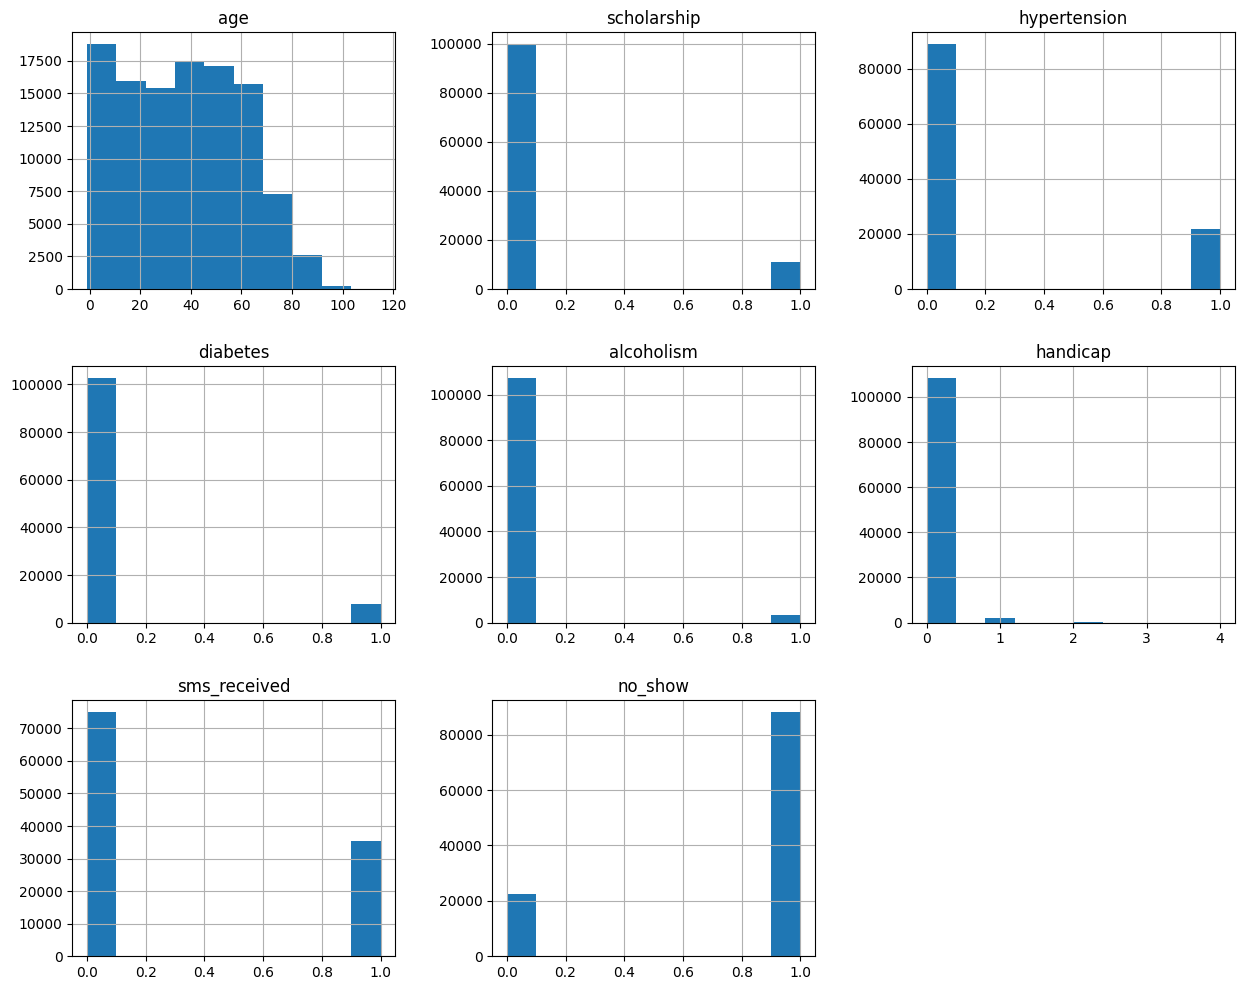

In [ ]:
#let's retrieve information of the columns in a histogram plotting
nsa2016_df.hist(figsize = (15,12));

> Less 25% of patients missed their medical appointment. In addition;

> The age histogram is skewed to the right, there's a possiblity that it could influence the chances of patients missing their medical appointment.

> Patients who are either **alcoholics**, **handicapped**, **hypertensive** or **diabetic** have medical conditions that are of concerns.

> Patients who are enrolled in the Bolsa Familia Welfare program are less under pressure to worry about their health.

> About 30% of the number of patients recieved sms reminders for their medical appointment. It could serve as a factor to determine if patients are likely to miss appointments.

### 2. What characteristics of patients actually influnced patients to miss their medical appointment


#### First, I will mask the element of the 'no_show' column with:

>'missed' for "0" element

>'showed_up' for the "1" element

In [ ]:
missed = nsa2016_df.no_show == False
showed_up = nsa2016_df.no_show == True

The effect of **age** on the scheduled appointment. First, let's observe the mean age.

In [ ]:
nsa2016_df.age.mean()

np.float64(37.08887421173107)

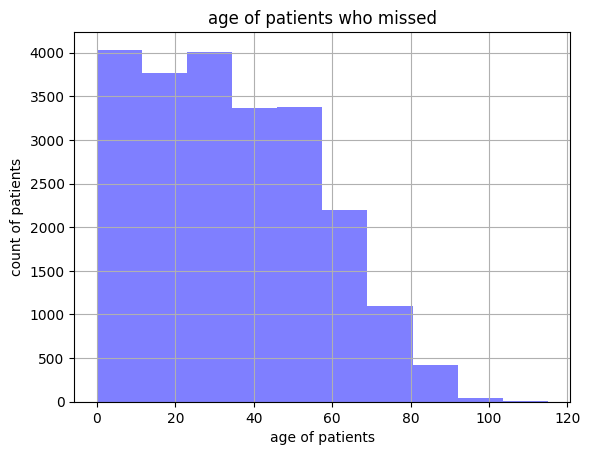

In [ ]:
#investigating the age characteristics of the patients and how it affected their showing up for their appointments
nsa2016_df.age[missed].hist(color = 'b', alpha = 0.5)
plt.title('age of patients who missed')
plt.xlabel('age of patients')
plt.ylabel('count of patients');

>The visuals explains that more patients above the mean age missed their appointment. In other words, age has an impart on the response of patients to their appointments.

The **Hypertensive patients** to their medical appointments

In [ ]:
nsa2016_df.hypertension[missed].value_counts()
nsa2016_df.hypertension[showed_up].value_counts()

,count
hypertension,
0,70179
1,18029


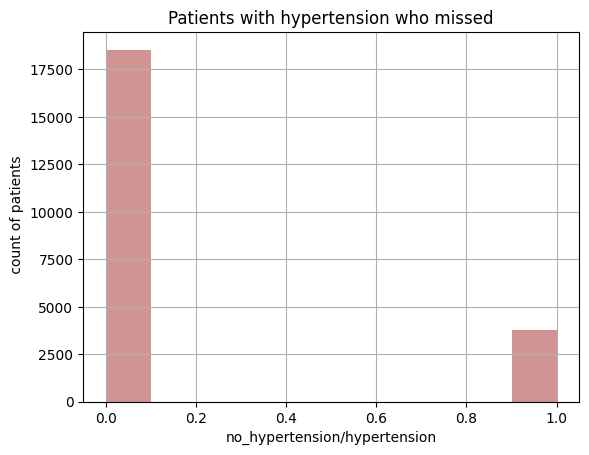

In [ ]:
#plotting to demostrate this
nsa2016_df.hypertension[missed].hist(alpha = 0.5, color = 'brown')
plt.ylabel(' count of patients')
plt.xlabel('no_hypertension/hypertension')
plt.title('Patients with hypertension who missed');

>The greater population of patients who missed their appointment had no hypertension. That means hypertension played no role in determing if the patients missed their appointment.

How about **handicap patients?**. Let me first classify them by groups

In [ ]:
#Grouping by number of handicaps
nsa2016_df.groupby('handicap').no_show.value_counts()

handicap  no_show
0         1          86374
          0          21912
1         1           1676
          0            366
2         1            146
          0             37
3         1             10
          0              3
4         1              2
          0              1
Name: count, dtype: int64

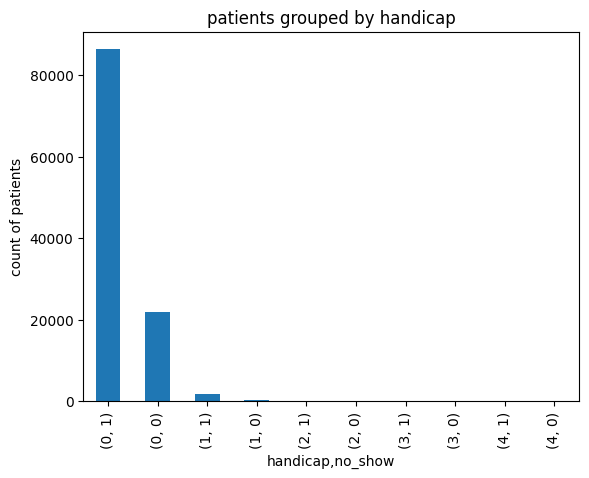

In [ ]:
#plotting to demostrate this
nsa2016_df.groupby('handicap').no_show.value_counts().plot(kind = 'bar')
plt.title('patients grouped by handicap')
plt.ylabel('count of patients');

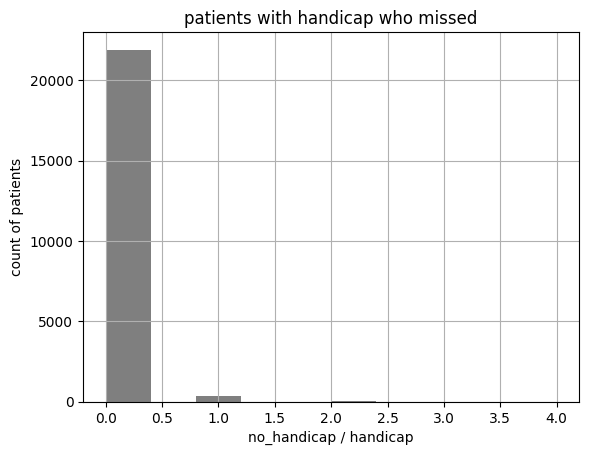

In [ ]:
#plotting to demostrate this
nsa2016_df.handicap[missed].hist(alpha = 0.5, color = 'black')
plt.ylabel('count of patients')
plt.xlabel('no_handicap / handicap')
plt.title('patients with handicap who missed');

> It seems like handicap plays no significant role in influencing patients to miss appointments. Within the population of patients who missed their medical appointments, only a small group are handicapped.

What **gender** is likely not to show up for their medical appointment?. First let's see their numbers

In [ ]:
nsa2016_df.gender.value_counts()

,count
gender,
F,71840
M,38687


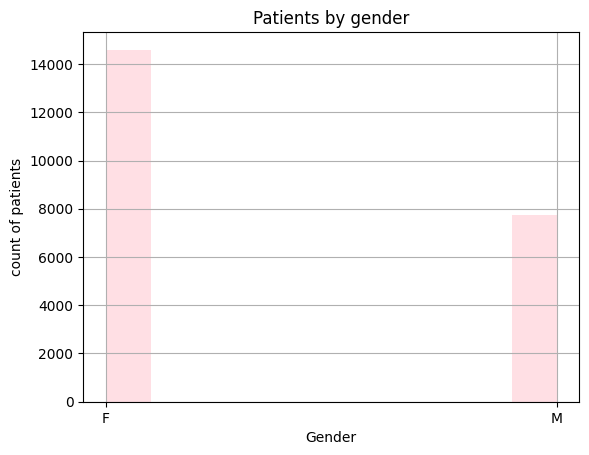

In [ ]:
#plotting to demostrate this
nsa2016_df.gender[missed].hist(alpha = 0.5, color = 'pink')
plt.ylabel('count of patients')
plt.xlabel('Gender')
plt.title('Patients by gender');

>As seen before, Female patients make up to 60% of the entire population hence it will be unfair to use this as an analytic too or parameter.

Since **welfare and sholarship** have a way of encouraging patients' healthy living, in what way does it affect patients showing up for their medical appointments?

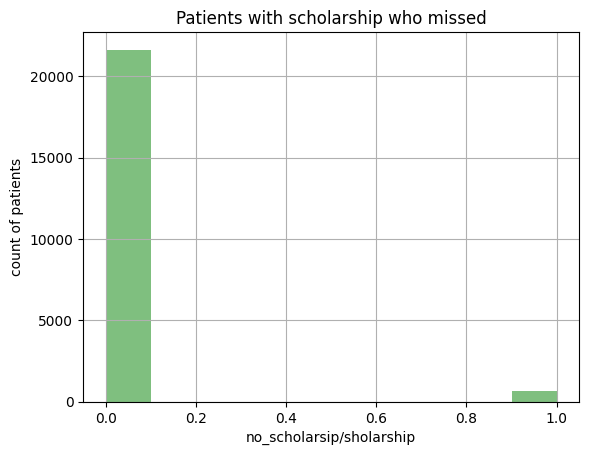

In [ ]:
#scholarship
nsa2016_df.alcoholism[missed].hist(alpha = 0.5, color = 'green')
plt.ylabel('count of patients')
plt.xlabel('no_scholarsip/sholarship')
plt.title('Patients with scholarship who missed');

> The patients who are on scholarship make up just an insignificant fraction of the population of patients who missed their appointment, hence it plays no role in influencing patients to miss their medical appointment.

It is most known that **alcoholism** as an addictive behaviour can serve as a great obstacle to certain lifestyle and health improvement. But, how has this affected whether patients missed their medical appointments? Let's explore this below;

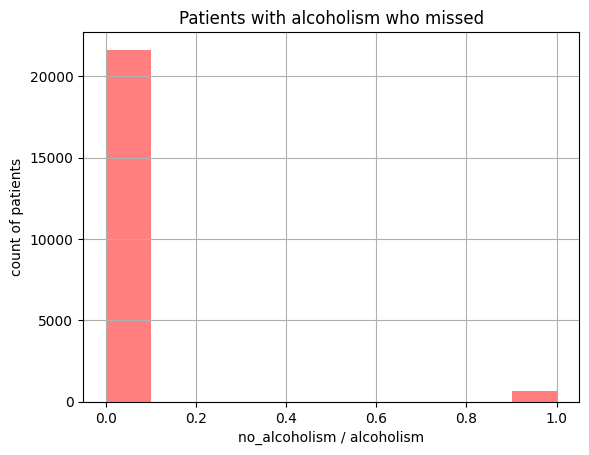

In [ ]:
#alcoholism
nsa2016_df.alcoholism[missed].hist(alpha = 0.5, color = 'red')
plt.ylabel('count of patients')
plt.xlabel('no_alcoholism / alcoholism')
plt.title('Patients with alcoholism who missed');

>The greater population of patients who missed their medical appointment are people who are not alcoholics. This suggest alcoholisms plays no role in determining if people miss medical appointments

**Sms and texts** reminders serve as excellent tools when it comes to reminding patients about their medical appointments. However, we shall still explore how **received sms** reminders affected how patients showed up for the medical appointments.

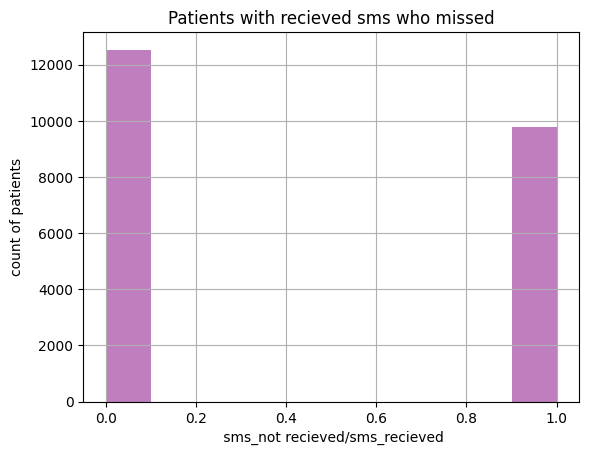

In [ ]:
#sms_received
nsa2016_df.sms_received[missed].hist(alpha = 0.5, color = 'purple')
plt.ylabel('count of patients')
plt.xlabel(' sms_not recieved/sms_recieved')
plt.title('Patients with recieved sms who missed');

>It looked like the sms reminders did do such a great work to influence patients to keep up with their medical appointments. Although, it was not a characteristic of a patient, it is still fine to explore this area.

<a id='conclusions'></a>
## Conclusions

> In summary, it looked like not much of a patients medical condition can influence a patient to miss an appointment. By previous critical examination, it had looked like medical conditions like alcoholism and handicap could make patients miss appointments; however the final analysis provided a contrary view. In other words, it means that patients are still likely to see their doctors on appointments despite limiting medical conditions like handicap and alcoholism.

> In addition, albeit having obvious outliers like -1years( although this did not possibly put our analysis to a bad state), age of patients looked like it influenced whether patients missed their appointments. This is a sound conclusion because a greater number of patients who missed their medical appointment are above the mean age. In other words, the older patients in the population missed their medical appointment. This could still sound counterintuitive if one considered that younger people has a lot to distract them from keeping up with appointments, however that is not the case here. This finding can also reveal that the health young population is considered significant in general.


>And finally, assessing the influence of Gender on whether patients missed their appointments or not, a limitation was encountered as the male gender made up about only 30-40% of the entire patients population.


